# 03 — Visualize an episode trace

This notebook records one deterministic episode to disk (JSONL), then
produces **three artifacts** that let you *see* what happened:

1. A **2D trajectory plot** (robot path + pedestrian positions) via matplotlib.
2. A **top-down map thumbnail** (PNG).
3. An **interactive Three.js browser viewer** (open `index.html`).

It reuses the exact recording + playback + viewer pipeline that powers
`uv run robot-sf demo` (see `scripts/demo/quickstart_demo.py`) — no new
logic, only the existing public APIs.

> CPU-only, headless, deterministic (fixed seed).

In [1]:
import os
import sys
from IPython import get_ipython

os.environ.setdefault("SDL_VIDEODRIVER", "dummy")


def _inline_matplotlib() -> None:
    # (Re-)arm the notebook inline backend for the next figure.
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "inline")


# Keep log output quiet so the executed notebook stays readable.
from loguru import logger
logger.remove()
logger.add(sys.stderr, level="ERROR")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Resolve the repo root robustly regardless of launch directory.
def _repo_root() -> Path:
    here = Path.cwd()
    for candidate in [here, *here.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return here

REPO_ROOT = _repo_root()

OUTPUT_DIR = REPO_ROOT / "output/notebooks/03_visualize_trace"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO_ROOT)
print("Artifacts will be written to:", OUTPUT_DIR.relative_to(REPO_ROOT))

Repo root: /home/luttkule/git/robot_sf_ll7.worktrees/cheap-issue-5798-20260715T225820Z
Artifacts will be written to: output/notebooks/03_visualize_trace


## 1. Run one deterministic, recorded episode

We build the environment with JSONL recording enabled, drive it with the
bundled random planner at a fixed seed, and stop the recording when the
episode finishes. The per-step simulation states are written to a `.jsonl`
file we can replay.

In [2]:
from robot_sf.gym_env.environment_factory import make_robot_env
from robot_sf.gym_env.robot_env import RobotEnv
from robot_sf.common.artifact_paths import resolve_artifact_path
from robot_sf.training.scenario_loader import load_scenarios, build_robot_config_from_scenario
from robot_sf.baselines.random_policy import RandomPlanner

SEED = 270
SCENARIO_NAME = "quickstart_demo_crossing_basic"
SCENARIO_PATH = REPO_ROOT / "configs/scenarios/single/quickstart_demo.yaml"

scenario = next(
    s for s in load_scenarios(SCENARIO_PATH) if s["name"] == SCENARIO_NAME
)
config = build_robot_config_from_scenario(scenario, scenario_path=SCENARIO_PATH)
recording_dir = resolve_artifact_path(OUTPUT_DIR / "recordings")

env: RobotEnv = make_robot_env(
    config=config,
    seed=SEED,
    debug=False,
    recording_enabled=True,
    use_jsonl_recording=True,
    recording_dir=str(recording_dir),
    suite_name="notebook",
    scenario_name=SCENARIO_NAME,
    algorithm_name="random",
    recording_seed=SEED,
)

planner = RandomPlanner({"mode": "velocity", "v_max": 1.5}, seed=SEED)
env.reset(seed=SEED)
planner.reset(seed=SEED)

steps = 0
terminated = truncated = False
while not truncated:
    decision = planner.step({"dt": 0.1, "robot": {}, "agents": []})
    action = np.array([float(decision["vx"]), float(decision["vy"])], dtype=np.float32)
    _obs, _reward, terminated, truncated, _info = env.step(action)
    steps += 1
    if terminated:
        break

env.end_episode_recording()
env.close_recorder()
env.exit()
print(f"Episode finished after {steps} steps.")

I0000 00:00:1784157912.545883 1037094 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784157912.577213 1037094 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784157913.142550 1037094 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784157913.142745 1037094 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Episode finished after 120 steps.


In [3]:
# Locate the recorded JSONL (the recorder names it with suite/scenario/algorithm/seed).
candidates = sorted(recording_dir.glob("*.jsonl"))
episode_jsonl = candidates[-1]
# Promote a stable copy next to the other artifacts.
stable_jsonl = OUTPUT_DIR / "episode.jsonl"
stable_jsonl.write_bytes(episode_jsonl.read_bytes())
print("Recorded episode:", episode_jsonl.name)
print("Stable copy:", stable_jsonl.relative_to(REPO_ROOT))

Recorded episode: notebook_quickstart_demo_crossing_basic_random_270_ep0000.jsonl
Stable copy: output/notebooks/03_visualize_trace/episode.jsonl


## 2. Load the recording and plot the trajectory

`JSONLPlaybackLoader` reads the JSONL back into a list of visualizable
states. Each state exposes the robot pose and the pedestrian positions, so
we can draw the robot's path and the pedestrians' final footprint.

Loaded 120 recorded states.
Saved: output/notebooks/03_visualize_trace/trace_trajectory.png


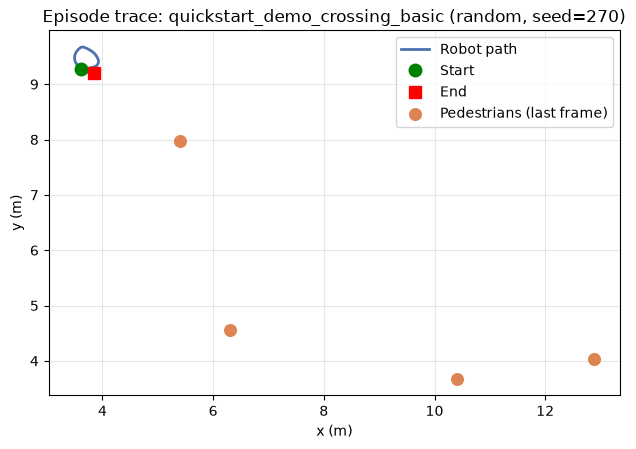

In [4]:
from robot_sf.render.jsonl_playback import JSONLPlaybackLoader

episode, map_def = JSONLPlaybackLoader().load_single_episode(stable_jsonl)
states = episode.states
print(f"Loaded {len(states)} recorded states.")

robot_path = np.array([s.robot_pose[0] for s in states])
# Final pedestrian positions (last recorded frame).
final_peds = states[-1].pedestrian_positions

_inline_matplotlib()
fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.plot(robot_path[:, 0], robot_path[:, 1], "-", color="#4C72B0", linewidth=2, label="Robot path")
ax.plot(robot_path[0, 0], robot_path[0, 1], "o", color="green", markersize=9, label="Start")
ax.plot(robot_path[-1, 0], robot_path[-1, 1], "s", color="red", markersize=9, label="End")
if final_peds.size:
    ax.scatter(final_peds[:, 0], final_peds[:, 1], c="#DD8452", s=70, label="Pedestrians (last frame)", zorder=5)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(f"Episode trace: {SCENARIO_NAME} (random, seed={SEED})")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()
plot_path = OUTPUT_DIR / "trace_trajectory.png"
fig.savefig(plot_path, dpi=120)
print("Saved:", plot_path.relative_to(REPO_ROOT))
plt.show()

## 3. Render a top-down map thumbnail

We reuse the map visualizer that the one-command demo uses.

In [5]:
from robot_sf.maps.map_visualizer import visualize_map_definition

thumbnail_path = OUTPUT_DIR / "map_thumbnail.png"
visualize_map_definition(map_def, output_path=thumbnail_path, title=f"{SCENARIO_NAME} (random)")
print("Saved:", thumbnail_path.relative_to(REPO_ROOT))

Saved: output/notebooks/03_visualize_trace/map_thumbnail.png


## 4. Export the interactive browser viewer

`export_threejs_viewer` turns the JSONL recording into a static
`index.html` Three.js scene you can open in any browser (no server
needed). Run the cell, then open the printed path.

In [6]:
from robot_sf.render.threejs_viewer import export_threejs_viewer

viewer_dir = OUTPUT_DIR / "viewer"
result = export_threejs_viewer(stable_jsonl, viewer_dir)
print("Open this file in a browser to watch the recording:")
try:
    viewer_rel = Path(result.html_path).relative_to(REPO_ROOT)
except ValueError:
    viewer_rel = Path(result.html_path)
print("  ", viewer_rel)
print("Viewer files:", sorted(p.name for p in viewer_dir.iterdir()))

Open this file in a browser to watch the recording:
   output/notebooks/03_visualize_trace/viewer/index.html
Viewer files: ['index.html', 'scene.json', 'viewer.js']


## Summary

Artifacts written under `output/notebooks/03_visualize_trace/`:

| File | What it is |
| --- | --- |
| `episode.jsonl` | The recorded per-step simulation states |
| `trace_trajectory.png` | Robot path + pedestrians (matplotlib) |
| `map_thumbnail.png` | Top-down map thumbnail |
| `viewer/index.html` | Interactive Three.js browser viewer |

You have now run an episode, **and** seen it three ways. These three
notebooks together form the beginner quickstart: **run → compare →
visualize**.